<a href="https://colab.research.google.com/github/fareehaikram93/assignment1-intern/blob/main/work/notebooks/ranking_signal_ml_pipeline_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ranking Signal ML Pipeline

Predicts `gsc_avg_position_90d` (lower = better ranking) from static content attributes, using the contracted dataset (`ranking_signal_content_grain_*.csv`, grain = one row per `client_hash_id` + `content_hash_id`).

**Task:** regression
**Label:** `gsc_avg_position_90d`
**Features:** content attributes from `dim_content` (see column contract in the manifest)
**Excluded from features:** `client_hash_id`, `content_hash_id` (identifiers), `days_observed` (quality signal, not a predictor)

**Missing values:** handled explicitly in Step 3 — audited, classified, and treated per-column (drop / indicator flag / impute), not silently dropped or blanket-filled. See Step 3 for the full explanation and the printed per-column decision table.


## 0. Load the contracted dataset

Upload `ranking_signal_content_grain_*.csv` and its `.manifest.json` (from the data-contract notebook) to the Colab file browser, then set the filenames below.

In [ ]:
import json
import pandas as pd

DATASET_PATH = '/content/ranking_signal_content_grain_20260811T100648Z.csv'
MANIFEST_PATH = '/content/ranking_signal_content_grain_20260811T100648Z.manifest.json'

df = pd.read_csv(DATASET_PATH)
with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

print(f'Rows: {len(df)}')
print(f"Contract version: {manifest['contract_version']}, grain: {manifest['grain']}")
df.head()

Rows: 100000
Contract version: 1.0.0, grain: ['client_hash_id', 'content_hash_id']


,client_hash_id,content_hash_id,gsc_avg_position_90d,days_observed,search_volume,competition,competition_level,cpc,char_count,main_intent,...,keyword_token_count,url_char_count,backlinks,category_count,word_count,content_type,provider_used,model_used,content_created_date,content_updated_date
0,client_73cda7b4e4f265ea,content_ef89ff748f7faed7,8.541545,91,0.0,0.00,LOW,0.00,19397.0,informational,...,5,83,0.0,0,2883.0,keyword article,google,gemini-3-flash-preview,2026-02-10,2026-05-20
1,client_73cda7b4e4f265ea,content_36166ace2994c2d6,17.373375,64,90.0,0.86,HIGH,0.27,NaN,transactional,...,6,91,NaN,0,NaN,keyword article,NaN,NaN,2025-03-03,2026-05-18
2,client_e547b89c05043229,content_f6963771704e02f9,6.866495,91,10.0,0.02,LOW,0.00,17435.0,informational,...,8,114,NaN,0,2715.0,keyword article,NaN,gemini-3-flash-preview,2025-02-07,2026-07-06
3,client_73cda7b4e4f265ea,content_efe1c906f4d7d66d,3.219822,91,40.0,0.01,LOW,0.00,NaN,informational,...,6,108,NaN,0,NaN,keyword article,NaN,NaN,2025-02-14,2026-05-18
4,client_73cda7b4e4f265ea,content_4d5bc13d6cfd81a6,6.780990,91,20.0,0.00,LOW,0.00,NaN,transactional,...,6,127,NaN,0,NaN,keyword article,NaN,NaN,2025-07-31,2026-07-01


## 1. Re-verify the contract before modeling

In [ ]:
pk_cols = manifest['grain']
errors = []

if df[pk_cols].isnull().any().any():
    errors.append('Primary key contains nulls')
if df.duplicated(subset=pk_cols).sum():
    errors.append(f"{df.duplicated(subset=pk_cols).sum()} duplicate grain keys")
if not df['gsc_avg_position_90d'].between(1, 100).all():
    errors.append('gsc_avg_position_90d out of plausible range')
if df['gsc_avg_position_90d'].isnull().any():
    errors.append('Label column contains nulls')

if errors:
    raise AssertionError('Contract check FAILED:\n- ' + '\n- '.join(errors))
print(f'✅ Contract re-verified — {len(df)} rows, unique keys confirmed.')

✅ Contract re-verified — 100000 rows, unique keys confirmed.


## 2. Define label and feature set

In [ ]:
LABEL = 'gsc_avg_position_90d'

ID_COLS = ['client_hash_id', 'content_hash_id']
EXCLUDE_COLS = ID_COLS + [LABEL, 'days_observed']

try:
    FEATURES = [c for c, meta in manifest['columns'].items() if meta.get('role') == 'feature']
except (KeyError, TypeError):
    FEATURES = [c for c in df.columns if c not in EXCLUDE_COLS]

print(f'Label:    {LABEL}')
print(f'Features ({len(FEATURES)}): {FEATURES}')

missing = [c for c in FEATURES + [LABEL] if c not in df.columns]
assert not missing, f'Columns missing from dataframe: {missing}'

Label:    gsc_avg_position_90d
Features (17): ['search_volume', 'competition', 'competition_level', 'cpc', 'char_count', 'main_intent', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'backlinks', 'category_count', 'word_count', 'content_type', 'provider_used', 'model_used', 'content_created_date', 'content_updated_date']


## 3. Missing value audit and treatment

**Why this matters:** a null in this dataset doesn't always mean the same thing. `search_volume` being null usually means "not found in the keyword provider," not "zero searches." `word_count` being null usually means a crawl/parse gap. Median-filling everything the same way would erase that distinction. So this step:

1. **Measures** how much each feature is missing.
2. **Checks whether missingness is informative** — does the label differ between rows where a feature is present vs. missing? If so, the fact that it's missing is itself a signal worth keeping, not noise to smooth over.
3. **Applies a rule per column**, printed explicitly below so nothing is a silent decision:
   - **`> DROP_THRESHOLD` missing** (default 50%) → column dropped from modeling entirely (too sparse to trust), but if missingness was informative, a `<col>_missing` flag is *kept* as a feature on its own.
   - **Numeric, some missing** → median-impute, **and** keep a `<col>_missing` binary indicator flag so the model can still use the fact that it was absent.
   - **Categorical, some missing** → impute with an explicit `"missing"` category (not the mode — that would invent a value you don't have) — the one-hot encoding then naturally captures it as its own level.
   - **No missing values** → passed through untouched.


In [ ]:
DROP_THRESHOLD = 0.50          # drop a column if more than this fraction is missing
INFORMATIVE_LABEL_DELTA = 0.5  # min difference in mean label (present vs missing) to call it "informative"

numeric_like = df[FEATURES].select_dtypes(include=['number']).columns.tolist()
categorical_like = [c for c in FEATURES if c not in numeric_like]

audit_rows = []
for col in FEATURES:
    pct_missing = df[col].isnull().mean()
    n_missing = int(df[col].isnull().sum())

    if n_missing > 0:
        mean_present = df.loc[df[col].notnull(), LABEL].mean()
        mean_missing = df.loc[df[col].isnull(), LABEL].mean()
        label_delta = abs(mean_present - mean_missing)
        informative = label_delta >= INFORMATIVE_LABEL_DELTA
    else:
        mean_present = mean_missing = label_delta = None
        informative = False

    is_numeric = col in numeric_like

    if pct_missing == 0:
        decision = 'none needed'
    elif pct_missing > DROP_THRESHOLD:
        decision = 'drop column' + (' + keep missing-flag (informative)' if informative else '')
    elif is_numeric:
        decision = 'median-impute' + (' + missing-flag (informative)' if informative else ' + missing-flag')
    else:
        decision = 'impute as explicit "missing" category'

    audit_rows.append({
        'feature': col,
        'type': 'numeric' if is_numeric else 'categorical',
        'pct_missing': round(pct_missing * 100, 1),
        'n_missing': n_missing,
        'label_mean_present': round(mean_present, 2) if mean_present is not None else None,
        'label_mean_missing': round(mean_missing, 2) if mean_missing is not None else None,
        'informative_missingness': informative,
        'decision': decision,
    })

missingness_audit = pd.DataFrame(audit_rows).sort_values('pct_missing', ascending=False)
pd.set_option('display.max_colwidth', 60)
missingness_audit

,feature,type,pct_missing,n_missing,label_mean_present,label_mean_missing,informative_missingness,decision
13,provider_used,categorical,58.2,58212,16.59,22.21,True,drop column + keep missing-flag (informative)
9,backlinks,numeric,30.4,30439,18.67,22.59,True,median-impute + missing-flag (informative)
4,char_count,numeric,20.6,20590,18.30,25.88,True,median-impute + missing-flag (informative)
11,word_count,numeric,20.6,20590,18.30,25.88,True,median-impute + missing-flag (informative)
14,model_used,categorical,16.3,16336,19.26,22.93,True,"impute as explicit ""missing"" category"
2,competition_level,categorical,3.5,3542,19.98,16.73,True,"impute as explicit ""missing"" category"
5,main_intent,categorical,3.0,2952,20.05,13.89,True,"impute as explicit ""missing"" category"
0,search_volume,numeric,2.5,2549,19.93,17.29,True,median-impute + missing-flag (informative)
1,competition,numeric,2.5,2549,19.93,17.29,True,median-impute + missing-flag (informative)
3,cpc,numeric,2.5,2549,19.93,17.29,True,median-impute + missing-flag (informative)


In [ ]:
# Apply the decisions from the audit table.
DROPPED_COLS, KEEP_AS_FLAG_ONLY, NUMERIC_KEEP, CATEGORICAL_KEEP = [], [], [], []

for _, row in missingness_audit.iterrows():
    col = row['feature']
    if row['decision'].startswith('drop column'):
        DROPPED_COLS.append(col)
        if row['informative_missingness']:
            KEEP_AS_FLAG_ONLY.append(col)
    elif row['type'] == 'numeric':
        NUMERIC_KEEP.append(col)
    else:
        CATEGORICAL_KEEP.append(col)

df_fe = df.copy()

# For dropped-but-informative columns, keep only a binary "was it missing" flag.
for col in KEEP_AS_FLAG_ONLY:
    df_fe[f'{col}_missing'] = df_fe[col].isnull().astype(int)

FLAG_ONLY_FEATURES = [f'{c}_missing' for c in KEEP_AS_FLAG_ONLY]

print('Dropped columns:               ', DROPPED_COLS or 'none')
print('Kept as missing-flag only:     ', KEEP_AS_FLAG_ONLY or 'none')
print(f'Numeric features kept ({len(NUMERIC_KEEP)}):    {NUMERIC_KEEP}')
print(f'Categorical features kept ({len(CATEGORICAL_KEEP)}): {CATEGORICAL_KEEP}')

Dropped columns:                ['provider_used']
Kept as missing-flag only:      ['provider_used']
Numeric features kept (10):    ['backlinks', 'char_count', 'word_count', 'search_volume', 'competition', 'cpc', 'url_char_count', 'keyword_char_count', 'keyword_token_count', 'category_count']
Categorical features kept (6): ['model_used', 'competition_level', 'main_intent', 'content_type', 'content_created_date', 'content_updated_date']


## 4. Feature engineering

Date columns become numeric "content age" features. If a date itself is missing, the derived feature is left as NaN too (not backfilled with today's date or a median) — it flows into the same missing-value handling as any other numeric feature above.

In [ ]:
SNAPSHOT_DATE = pd.Timestamp(manifest['snapshot_date'])

for col in ['content_created_date', 'content_updated_date']:
    if col in df_fe.columns:
        df_fe[col] = pd.to_datetime(df_fe[col], errors='coerce')

if 'content_created_date' in df_fe.columns and 'content_created_date' not in DROPPED_COLS:
    df_fe['content_age_days'] = (SNAPSHOT_DATE - df_fe['content_created_date']).dt.days
    NUMERIC_KEEP = [c for c in NUMERIC_KEEP if c != 'content_created_date'] + ['content_age_days']

if 'content_updated_date' in df_fe.columns and 'content_updated_date' not in DROPPED_COLS:
    df_fe['days_since_update'] = (SNAPSHOT_DATE - df_fe['content_updated_date']).dt.days
    NUMERIC_KEEP = [c for c in NUMERIC_KEEP if c != 'content_updated_date'] + ['days_since_update']

RAW_DATE_COLS = [c for c in ['content_created_date', 'content_updated_date'] if c in df_fe.columns]
numeric_features = [c for c in NUMERIC_KEEP if c not in RAW_DATE_COLS]
categorical_features = CATEGORICAL_KEEP

FEATURES_FE = numeric_features + categorical_features + FLAG_ONLY_FEATURES

print(f'Final feature count: {len(FEATURES_FE)}')
print(f'  numeric:      {numeric_features}')
print(f'  categorical:  {categorical_features}')
print(f'  flag-only:    {FLAG_ONLY_FEATURES}')

Final feature count: 19
  numeric:      ['backlinks', 'char_count', 'word_count', 'search_volume', 'competition', 'cpc', 'url_char_count', 'keyword_char_count', 'keyword_token_count', 'category_count', 'content_age_days', 'days_since_update']
  categorical:  ['model_used', 'competition_level', 'main_intent', 'content_type', 'content_created_date', 'content_updated_date']
  flag-only:    ['provider_used_missing']


## 5. Train / test split

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.2

X = df_fe[FEATURES_FE]
y = df_fe[LABEL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (80000, 19), Test: (20000, 19)


## 6. Preprocessing pipeline

- **Numeric features:** `SimpleImputer(strategy='median', add_indicator=True)` — this both fills the value AND automatically appends a `missingindicator_*` column per numeric feature that had any nulls in the training fold, so the "was this missing" signal survives into the model even for features not flagged as informative above.
- **Categorical features:** imputed with the literal string `'missing'` before one-hot encoding, so "missing" becomes its own explicit category rather than being folded into the most common one.
- **Flag-only features** (from dropped-but-informative columns): already 0/1, passed through as numeric.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

flag_transformer = 'passthrough'

transformers = [('num', numeric_transformer, numeric_features)]
if categorical_features:
    transformers.append(('cat', categorical_transformer, categorical_features))
if FLAG_ONLY_FEATURES:
    transformers.append(('flag', flag_transformer, FLAG_ONLY_FEATURES))

preprocessor = ColumnTransformer(transformers=transformers)

## 7. Baseline model

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)

print(f'Baseline (predict train mean) — MAE: {baseline_mae:.3f}, RMSE: {baseline_rmse:.3f}')

Baseline (predict train mean) — MAE: 11.302, RMSE: 14.560


## 8. Candidate models

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

models = {
    'ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'random_forest': RandomForestRegressor(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'gradient_boosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE
    ),
}

pipelines = {
    name: Pipeline(steps=[('preprocess', preprocessor), ('model', model)])
    for name, model in models.items()
}

## 9. Cross-validation

In [ ]:
from sklearn.model_selection import cross_val_score

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(
        pipe, X_train, y_train, cv=5,
        scoring='neg_mean_absolute_error', n_jobs=-1
    )
    cv_results[name] = -scores
    print(f'{name:18} CV MAE: {-scores.mean():.3f} (+/- {scores.std():.3f})')

ridge              CV MAE: 9.130 (+/- 0.048)
random_forest      CV MAE: 9.259 (+/- 0.050)
gradient_boosting  CV MAE: 9.180 (+/- 0.050)


## 10. Fit best model and evaluate on the held-out test set

In [ ]:
best_name = min(cv_results, key=lambda n: cv_results[n].mean())
best_pipe = pipelines[best_name]
print(f'Best model by CV MAE: {best_name}')

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'\nTest set performance ({best_name}):')
print(f'  MAE:  {mae:.3f}  (baseline: {baseline_mae:.3f})')
print(f'  RMSE: {rmse:.3f}  (baseline: {baseline_rmse:.3f})')
print(f'  R2:   {r2:.3f}')

Best model by CV MAE: ridge

Test set performance (ridge):
  MAE:  9.106  (baseline: 11.302)
  RMSE: 11.997  (baseline: 14.560)
  R2:   0.321


## 11. Diagnostics: predicted vs. actual, residuals

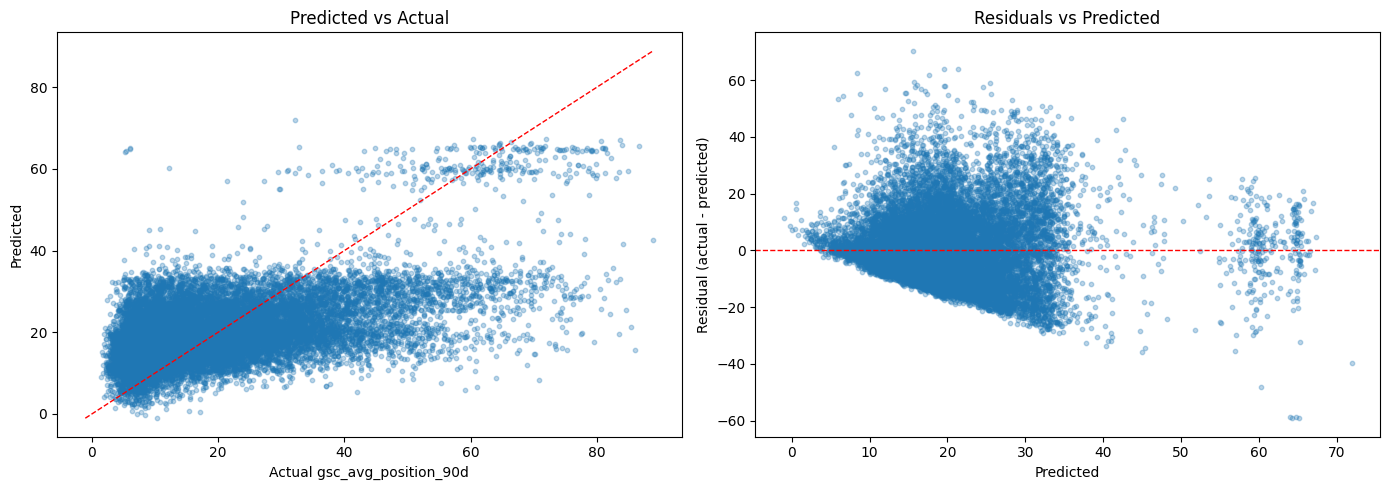

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual gsc_avg_position_90d')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Predicted vs Actual')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

## 12. Feature importance

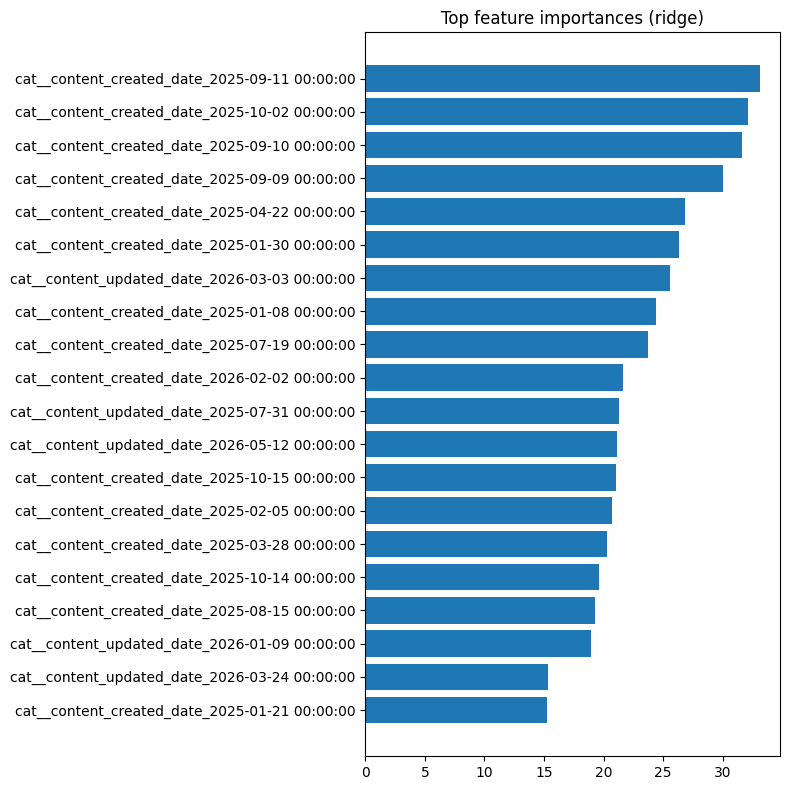

In [ ]:
fitted_preprocessor = best_pipe.named_steps['preprocess']
feature_names = fitted_preprocessor.get_feature_names_out()
fitted_model = best_pipe.named_steps['model']

if hasattr(fitted_model, 'feature_importances_'):
    importances = fitted_model.feature_importances_
elif hasattr(fitted_model, 'coef_'):
    importances = np.abs(fitted_model.coef_)
else:
    importances = None

if importances is not None:
    importance_df = (
        pd.DataFrame({'feature': feature_names, 'importance': importances})
        .sort_values('importance', ascending=False)
        .head(20)
    )
    plt.figure(figsize=(8, 8))
    plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
    plt.title(f'Top feature importances ({best_name})')
    plt.tight_layout()
    plt.show()
    importance_df
else:
    print('Selected model has no native importance/coefficient attribute.')

## 13. Permutation importance (model-agnostic sanity check)

In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_pipe, X_test, y_test, n_repeats=10,
    random_state=RANDOM_STATE, scoring='neg_mean_absolute_error', n_jobs=-1
)

perm_df = (
    pd.DataFrame({
        'feature': X_test.columns,
        'importance_mean': perm_result.importances_mean,
        'importance_std': perm_result.importances_std,
    })
    .sort_values('importance_mean', ascending=False)
)

perm_df.head(15)

,feature,importance_mean,importance_std
16,content_created_date,2.199678,0.028485
17,content_updated_date,0.831912,0.015935
12,model_used,0.577247,0.009472
2,word_count,0.251652,0.008379
10,content_age_days,0.168529,0.005273
4,competition,0.164496,0.007861
18,provider_used_missing,0.127696,0.008561
15,content_type,0.076294,0.003989
14,main_intent,0.057462,0.005935
13,competition_level,0.033892,0.003354


## 14. Save the model artifact

The manifest now also records the missing-value audit and decisions, so anyone reusing this model later knows exactly how nulls were handled without re-deriving it.

In [ ]:
import joblib
import datetime as dt

run_ts = dt.datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')
model_filename = f'ranking_signal_model_{best_name}_{run_ts}.joblib'
model_manifest_filename = f'ranking_signal_model_{best_name}_{run_ts}.manifest.json'

joblib.dump(best_pipe, model_filename)

model_manifest = {
    'model_type': best_name,
    'trained_at_utc': run_ts,
    'data_contract_version': manifest.get('contract_version'),
    'data_manifest_source': MANIFEST_PATH,
    'label': LABEL,
    'features': FEATURES_FE,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'flag_only_features': FLAG_ONLY_FEATURES,
    'missing_value_handling': {
        'drop_threshold': DROP_THRESHOLD,
        'informative_label_delta': INFORMATIVE_LABEL_DELTA,
        'dropped_columns': DROPPED_COLS,
        'kept_as_flag_only': KEEP_AS_FLAG_ONLY,
        'audit_table': missingness_audit.to_dict(orient='records'),
    },
    'train_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
    'test_size': TEST_SIZE,
    'random_state': RANDOM_STATE,
    'metrics': {
        'baseline_mae': float(baseline_mae),
        'baseline_rmse': float(baseline_rmse),
        'test_mae': float(mae),
        'test_rmse': float(rmse),
        'test_r2': float(r2),
    },
}

with open(model_manifest_filename, 'w') as f:
    json.dump(model_manifest, f, indent=2)

print(f'Wrote {model_filename}')
print(f'Wrote {model_manifest_filename}')

Wrote ranking_signal_model_ridge_20260811T110533Z.joblib
Wrote ranking_signal_model_ridge_20260811T110533Z.manifest.json


/tmp/ipykernel_1710/3553525122.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_ts = dt.datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')
